# Q41. Why is Exploratory Data Analysis (EDA) important before model building?

Exploratory Data Analysis (EDA) is important because it helps us understand the dataset before building a model. It identifies missing values, outliers, feature distributions, relationships between variables, and data quality issues that can affect model performance.
For example: df.head(),df.info() to see data type and null value, df.duplicated().sum()


In [1]:
# Q42. What insights can you obtain from summary statistics?
# Summary statistics provide a quick overview of the dataset.
# They help us understand the spread, distribution, and presence of potential outliers in numerical features.
""" 
From summary statistics, we can obtain:

Count → Number of non-missing values.
Mean → Average value.
Standard Deviation → Spread of the data.
Minimum & Maximum → Smallest and largest values.
25%, 50% (Median), 75% → Distribution of the data and potential outliers.

"""
import pandas as pd
df=pd.DataFrame({
    'age':[10,20,30,40,50,60,70,80,90,100]
})
print(df.describe())

              age
count   10.000000
mean    55.000000
std     30.276504
min     10.000000
25%     32.500000
50%     55.000000
75%     77.500000
max    100.000000


            hour_study  marks_ob
hour_study    1.000000  0.972019
marks_ob      0.972019  1.000000


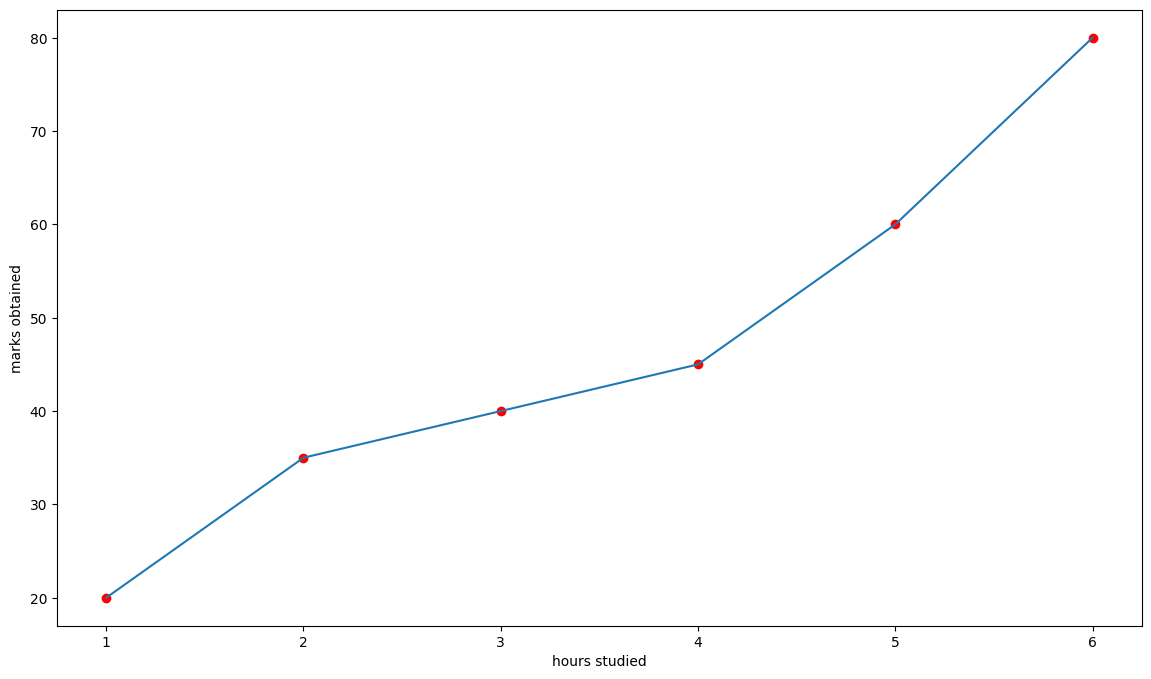

In [15]:
# Q43. How do you identify relationships between features during EDA?
# During EDA, relationships between features can be identified using correlation analysis and visualization techniques such as scatter plots, pair plots, and heatmaps.
df=pd.DataFrame({
    'hour_study':[1,2,3,4,5,6],
    'marks_ob':[20,35,40,45,60,80]
})
print(df.corr())
import matplotlib.pyplot as plt
plt.figure(figsize=(14,8))
plt.scatter(x=df['hour_study'],y=df['marks_ob'],c='red',marker='o')
sns.lineplot(data=df,x='hour_study',y='marks_ob')
plt.xlabel('hours studied')
plt.ylabel('marks obtained')
plt.show()
import seaborn as sns


skewness value: 2.2296415673746433


(array([4., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([  100.,  1090.,  2080.,  3070.,  4060.,  5050.,  6040.,  7030.,
         8020.,  9010., 10000.]),
 <BarContainer object of 10 artists>)

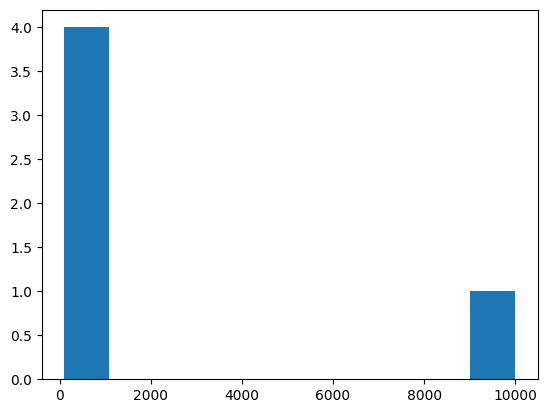

In [ ]:
# Q44. How do you identify skewed data distributions?
# Skewed data distributions can be identified using histograms, box plots, and the skewness value.
# These methods show whether the data is symmetric or has a longer tail on one side.
"""
Histogram → Shows the shape of the data distribution.
Box Plot → Helps identify skewness and outliers.
Skewness Value
Skewness = 0 → Symmetric distribution
Skewness > 0 → Positively (right) skewed
Skewness < 0 → Negatively (left) skewed
"""
df=pd.DataFrame({
    'salary':[100,200,300,500,10000]
})
print(f"skewness value: {df['salary'].skew()}")
plt.hist(df['salary'],bins=10) # bins : devide in interval

""" Histogram → Understands the distribution (normal, skewed, etc.).
Box Plot → Identifies outliers and spread of the data.
Scatter Plot → Finds the relationship or correlation between two numerical features.
Pair Plot → Compares relationships between all numerical features at once."""

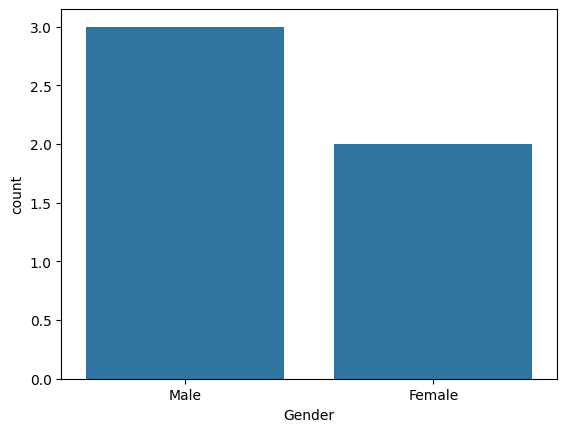

<Axes: ylabel='count'>

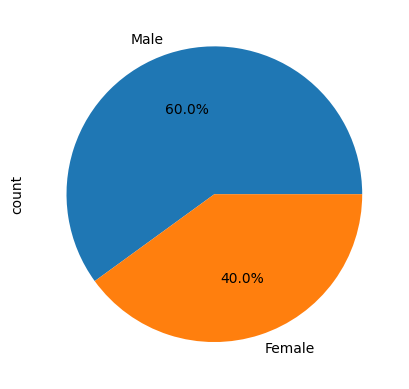

In [33]:
# Q46. What visualizations would you use for categorical features?
#or categorical features, the most commonly used visualizations are:
# Count Plot (Bar Plot) → Shows the frequency of each category.
# Pie Chart → Shows the proportion of each category.
import seaborn as sns
df = pd.DataFrame({
    'Gender': ['Male', 'Female', 'Male', 'Male', 'Female']
})
sns.countplot(data=df, x='Gender')
plt.show()
df['Gender'].value_counts().plot(kind='pie',autopct='%1.1f%%')

Q48. During EDA, you discover that 90% of the values in one feature are missing. What factors
would you consider before deciding whether to remove the feature or retain it?

A feature with 90% missing values is usually a candidate for removal.However, if it is highly important or the missing values themselves carry useful information, it may be worth retaining and handling appropriately.


In [48]:
"""Q49. A dataset contains both numerical and categorical features with missing values, duplicate
records, inconsistent categories, and outliers. Describe the sequence of preprocessing steps you
would follow before training a mode

Remove duplicates.
Handle missing values.
Correct inconsistent categories.
Detect and treat outliers.
"""
import numpy as np
df = pd.DataFrame({
    'Age': [25, 30, None, 40, None],
    'City': ['Mumbai', np.nan, 'Delhi', 'Mumbai', 'Pune']
})
from IPython.display import display
display(df)
print(" imputing the missing value ")
# separating into num_col and cat_col
num_col=df[['Age']]
cat_col=df[['City']]
from sklearn.impute import SimpleImputer
# SimpleImputer.fit_transform() expects a 2D DataFrame.
num_imputer=SimpleImputer(strategy='mean')
df[['Age']]=num_imputer.fit_transform(num_col)
col_imputer=SimpleImputer(strategy='most_frequent')
df[['City']]=col_imputer.fit_transform(cat_col)
display(df)

,Age,City
0,25.0,Mumbai
1,30.0,NaN
2,NaN,Delhi
3,40.0,Mumbai
4,NaN,Pune


 imputing the missing value 


,Age,City
0,25.000000,Mumbai
1,30.000000,Mumbai
2,31.666667,Delhi
3,40.000000,Mumbai
4,31.666667,Pune
